In [ ]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import sys

sys.path.append('..')

# Preparing synthetic data

In [55]:
RANDOM_STATE = 264034
N_SAMPLES = 2634

[0 1 2 3 4 5 6 7]
[1318 1316]


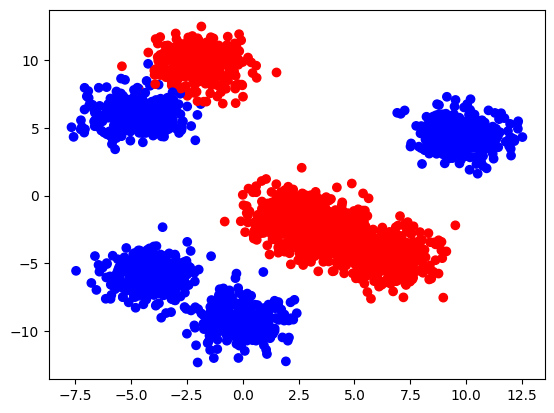

In [56]:
X_multi_claster, y_multi_claster = make_blobs(n_samples = N_SAMPLES, random_state = RANDOM_STATE, n_features=2, centers=8) # type: ignore

print(np.unique(y_multi_claster))
y_multi_claster = np.where( y_multi_claster > 3 , 1, 0)
print(np.bincount(y_multi_claster))

plt.scatter(X_multi_claster[:,0], X_multi_claster[:,1], c=y_multi_claster, cmap="bwr")
plt.show()

________

# Implementation of neural network

## Activation functions

In [57]:
def heaviside(s):
    return np.where(s >= 0, 1, 0)

def heaviside_derivative(s):
    return 1

def sigmoid(s):
    return 1/(1+np.exp(-s))

def sigmoid_derivative(s):
    return (np.exp(-s)/(1+np.exp(-s))**2)

def sin(s):
    return np.sin(s)

def sin_derivative(s):
    return np.cos(s)

def tanh(s):
    return np.tanh(s)

def tanh_derivative(s):
    return 1 - np.tanh(s)**2

def sign(s):
    return np.sign(s)

def sign_derivative(s):
    return 1

def relu(s):
    return np.maximum(0, s)

def relu_derivative(s):
    return np.where(s >= 0, 1.0, 0.0)

def leaky_relu(s):
    return np.where(s > 0, s, 0.01 * s)

def leaky_relu_derivative(s):
    return np.where(s > 0, 1.0, 0.01)

## Neural Network implementation

In [58]:
class NeuralNetwork:
    def __init__(self, layers : list, activ_func, deriv_func, learning_rate = 0.1) -> None:
        self.num_layers = len(layers)
        self.layers_sizes = layers
        self.activation = activ_func
        self.derivative = deriv_func
        self.learning_rate = learning_rate
        if activ_func is relu:
            self.weights = [np.random.randn(y,x) * np.sqrt(2 / x) for x, y in zip(self.layers_sizes[:-1], self.layers_sizes[1:])]
            self.biases = [np.random.randn(y, 1) for y in self.layers_sizes[1:]]
        else:
            self.weights = [np.random.randn(y,x) for x, y in zip(self.layers_sizes[:-1], self.layers_sizes[1:])]
            self.biases = [np.random.randn(y, 1) for y in self.layers_sizes[1:]]
    
    def predict(self, input):
        output = input
        for bias, weight in zip(self.biases, self.weights):
            output = self.activation(np.dot(weight, output) + bias)

        return output

    def forwardpass(self, input):
        activation = input
        activations = [activation]
        outputs = []
        for bias, weight in zip(self.biases, self.weights):
            z = np.dot(weight, activation) + bias
            activated_z = self.activation(z)
            outputs.append(z)
            activations.append(activated_z)

            activation = activated_z

        return activations, outputs

    def backpropagation(self, x, d):
        activations, zs = self.forwardpass(x)
        nabla_biases = [np.zeros(layer.shape) for layer in self.biases]
        nabla_weights = [np.zeros(layer.shape) for layer in self.weights]

        delta = (activations[-1] - d) * self.derivative(zs[-1])
        nabla_weights[-1] = self.learning_rate * np.dot(delta, activations[-2].T)
        nabla_biases[-1] = self.learning_rate * delta

        for layer in range(2, self.num_layers):
            delta = np.dot(self.weights[-layer+1].T, delta) * self.derivative(zs[-layer])    
            nabla_weights[-layer] = self.learning_rate * np.dot(delta, activations[-layer-1].T)
            nabla_biases[-layer] = self.learning_rate * delta
        
        # self.weights = [w - nw for w, nw in zip(self.weights, nabla_weights)]
        # self.biases = [b - nb for b, nb in zip(self.biases, nabla_biases)]

        return nabla_weights, nabla_biases
    
    def train_batch(self, X, D, batch_size=4, epochs=10000):
        n = len(X)
        for epoch in tqdm(range(epochs), desc="Training epochs"):
            indices = np.arange(n)
            np.random.shuffle(indices)
            X_shuffled = [X[i] for i in indices]
            D_shuffled = [D[i] for i in indices]

            for k in range(0, n, batch_size):
                X_batch = X_shuffled[k:k+batch_size]
                D_batch = D_shuffled[k:k+batch_size]

                total_nabla_w = [np.zeros(w.shape) for w in self.weights]
                total_nabla_b = [np.zeros(b.shape) for b in self.biases]

                for x, d in zip(X_batch, D_batch):
                    nabla_w, nabla_b = self.backpropagation(x, d)
                    total_nabla_w = [sdw + dw_i for sdw, dw_i in zip(total_nabla_w, nabla_w)]
                    total_nabla_b = [sdb + db_i for sdb, db_i in zip(total_nabla_b, nabla_b)]

                num_samples = len(X_batch)
                self.weights = [w - (1 / num_samples) * dw for w, dw in zip(self.weights, total_nabla_w)]
                self.biases = [b - (1 / num_samples) * db for b, db in zip(self.biases, total_nabla_b)]

            # if epoch % 200 == 0:
            #     loss = np.mean([(self.predict(x) - d)**2 for x, d in zip(X, D)])
            #     print(f"Epoch {epoch}, Loss: {loss:.6f}")

_______

# Testing on synthetic datset

## Preparing dataset into column vectors

In [59]:
X_train_blobs, X_test_blobs, y_train_blobs, y_test_blobs = train_test_split(
    X_multi_claster, y_multi_claster, test_size=0.3, random_state=RANDOM_STATE, stratify=y_multi_claster)

X_train_cols = [x.reshape(-1, 1) for x in X_train_blobs]
X_test_cols  = [x.reshape(-1, 1) for x in X_test_blobs]

num_classes = 2
y_train_onehot = np.eye(num_classes)[y_train_blobs]
y_test_onehot  = np.eye(num_classes)[y_test_blobs]

y_train_cols = [row.reshape(-1, 1) for row in y_train_onehot]
y_test_cols  = [row.reshape(-1, 1) for row in y_test_onehot]

## util functions

In [60]:
def predict_class(net : NeuralNetwork, x_col):
    out = net.predict(x_col)
    return int(np.argmax(out))

def plot_decision_boundary(net, X, y, resolution=0.02):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                            np.arange(y_min, y_max, resolution))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    Z = [predict_class(net, p.reshape(-1, 1)) for p in grid_points]
    Z = np.array(Z).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
    plt.title("Decision Boundary")
    plt.show()

## Training and testing with sigmoid

(1843, 2)


Training epochs: 100%|██████████| 200/200 [00:13<00:00, 15.30it/s]



Test accuracy: 0.9912


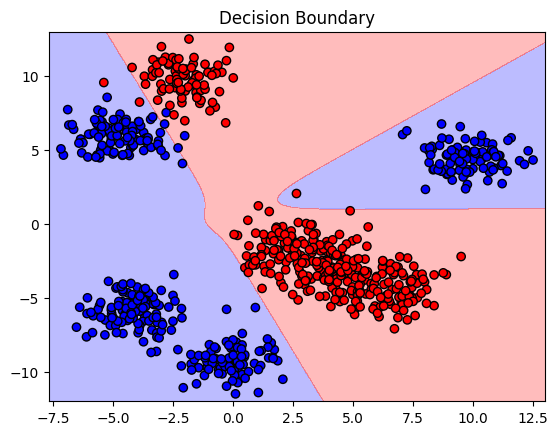

In [61]:
nn = NeuralNetwork([2, 5, 5, 2], sigmoid, sigmoid_derivative)

print(X_train_blobs.shape)

nn.train_batch(X_train_cols, y_train_cols, batch_size=32, epochs=200)

y_pred = [predict_class(nn, x) for x in X_test_cols]
accuracy = np.mean(y_pred == y_test_blobs)
print(f"\nTest accuracy: {accuracy:.4f}")
plot_decision_boundary(nn, X_test_blobs, y_test_blobs)

## Training and testing with relu

(1843, 2)


Training epochs: 100%|██████████| 200/200 [00:10<00:00, 19.59it/s]



Test accuracy: 0.9874


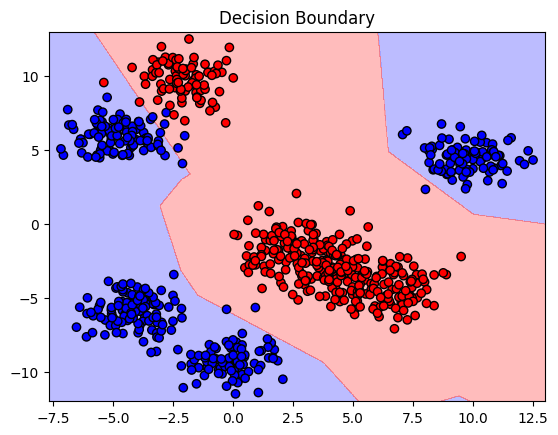

In [62]:
nn = NeuralNetwork([2, 5, 5, 2], relu, relu_derivative)

print(X_train_blobs.shape)

nn.train_batch(X_train_cols, y_train_cols, batch_size=32, epochs=200)

y_pred = [predict_class(nn, x) for x in X_test_cols]
accuracy = np.mean(y_pred == y_test_blobs)
print(f"\nTest accuracy: {accuracy:.4f}")
plot_decision_boundary(nn, X_test_blobs, y_test_blobs)

____

# Testing on real dataset

In [73]:
from sklearn.datasets import fetch_openml

In [74]:
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.to_numpy().astype(np.float32)
X /= 255.0
y = mnist.target.to_numpy().astype(int)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

X_train = [x.reshape(784,1) for x in X_train]
D_train = [np.eye(10)[:, d].reshape(10, 1) for d in y_train]

X_test = [x.reshape(784,1) for x in X_test]
D_test = [np.eye(10)[:, d].reshape(10, 1) for d in y_test]

In [88]:
layers = [784, 30, 30, 10]
nn = NeuralNetwork(layers, sigmoid, sigmoid_derivative)

nn.train_batch(X_train, D_train, epochs=10)

Training epochs: 100%|██████████| 10/10 [00:58<00:00,  5.84s/it]


In [89]:
def predict_class(net, x_col):
    out = net.predict(x_col)
    return int(np.argmax(out))

y_pred = [predict_class(nn, x) for x in X_test]
accuracy = np.mean(y_pred == y_test)
print(f"\nTest accuracys: {accuracy:.4f}")


Test accuracys: 0.9042
